[![Open in GitHub](https://img.shields.io/badge/Open%20Folder%20in-GitHub-181717?logo=github&logoColor=white)](https://github.com/lindsayalexandra14/ds_portfolio/tree/main/1_projects/data_visualization/python_eda/divorce)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lindsayalexandra14/ds_portfolio/blob/main/1_projects/data_visualization/python_eda/divorce/divorce_eda.ipynb)


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/EDA%20divorce.png)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Introduction.png)

This is an Exploratory Data Analysis (EDA) on a "divorce" dataset featuring ~2K couples who divorced in Mexico from 2000-2015. It visualizes the basic stats of the data, explores relationships between variables, creates new features to help with additional insights, and performs a linear regression to see how well the data explain marriage duration.



*  Author: Lindsay McFarlane
*  Data Source: DataCamp



In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split as holdout
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Import%20Data.png)

Import data from github:

In [2]:
!wget "https://raw.githubusercontent.com/lindsayalexandra14/ds_portfolio/refs/heads/main/1_projects/data_visualization/python_eda/divorce/divorce.csv"


--2025-11-14 21:42:51--  https://raw.githubusercontent.com/lindsayalexandra14/ds_portfolio/refs/heads/main/1_projects/data_visualization/python_eda/divorce/divorce.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 199155 (194K) [text/plain]
Saving to: ‘divorce.csv’

divorce.csv         100%[===================>] 194.49K  --.-KB/s    in 0.03s   

2025-11-14 21:42:52 (7.58 MB/s) - ‘divorce.csv’ saved [199155/199155]



In [3]:
df = pd.read_csv("divorce.csv")

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Import%20Libraries.png)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/View%20Data.png)

View first rows:

In [4]:
df.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,NaN
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,NaN
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,NaN


View shape of data:

*   2,209 rows and 10 features



In [5]:
df.shape

(2209, 10)

View names of all 10 features/columns:

In [6]:
df.columns

Index(['divorce_date', 'dob_man', 'education_man', 'income_man', 'dob_woman',
       'education_woman', 'income_woman', 'marriage_date', 'marriage_duration',
       'num_kids'],
      dtype='object')

View datatypes and non-null values:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   divorce_date       2209 non-null   object 
 1   dob_man            2209 non-null   object 
 2   education_man      2205 non-null   object 
 3   income_man         2209 non-null   float64
 4   dob_woman          2209 non-null   object 
 5   education_woman    2209 non-null   object 
 6   income_woman       2209 non-null   float64
 7   marriage_date      2209 non-null   object 
 8   marriage_duration  2209 non-null   float64
 9   num_kids           1333 non-null   float64
dtypes: float64(4), object(6)
memory usage: 172.7+ KB


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Missing%20Values.png)

"num_kids" and "education_man" had missing values:

In [8]:
df["num_kids"].unique()

array([ 1., nan,  2.,  3.,  5.,  4.])

In [9]:
df["education_man"].unique()

array(['Secondary', 'Professional', 'Preparatory', 'Primary', 'Other',
       nan], dtype=object)

Create dataframe of features with their count and % of missing values (if above 0 -> they had missing values):

In [10]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
num_kids,876,39.655953
education_man,4,0.181077


Fill missing values for num_kids as 0:

In [11]:
df["num_kids"]=df["num_kids"].fillna(0)

Drop rows with missing values for "education_man":

In [12]:
df = df.dropna(subset=["education_man"])

In [13]:
df.shape

(2205, 10)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Duplicates.png)

Check for duplicates:

In [14]:
df.duplicated().sum()

np.int64(0)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Summary%20Statistics.png)

View summary statistics for numerical features:

In [15]:
df.describe()

,income_man,income_woman,marriage_duration,num_kids
count,2205.000000,2205.000000,2205.000000,2205.000000
mean,7931.327429,6800.635138,9.611338,1.008617
std,7698.112975,6566.382414,7.270129,0.996554
min,3.000000,3.500000,1.000000,0.000000
25%,3600.000000,3000.000000,4.000000,0.000000
50%,6000.000000,5000.000000,8.000000,1.000000
75%,10000.000000,8000.000000,14.000000,2.000000
max,80000.000000,90000.000000,32.000000,5.000000


View range of dates for "divorce_date":

In [16]:
df["divorce_date"].min()

'2000-01-08'

In [17]:
df["divorce_date"].max()

'2015-11-03'

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Formatting.png)

Convert "divorce_date" and "marriage_date" to datetime:

In [18]:
df['marriage_date'] = pd.to_datetime(df['marriage_date'])
df['divorce_date'] = pd.to_datetime(df['divorce_date'])
df['dob_man'] = pd.to_datetime(df['dob_man'])
df['dob_woman'] = pd.to_datetime(df['dob_woman'])

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Feature%20Engineering.png)

Age Differences:

Absolute Difference:

In [19]:
df["age_difference"]=abs(df["dob_man"]-df["dob_woman"])

In [20]:
df["age_difference"] = df["age_difference"].dt.days // 365

In [21]:
df["days_man_older"]=df["dob_man"]-df["dob_woman"]

In [22]:
df["days_woman_older"]=df["dob_woman"]-df["dob_man"]

Convert age difference to # of years:

In [23]:
df["years_man_older"] = np.trunc(df["days_man_older"].dt.days / 365).astype(int)

In [24]:
df["years_woman_older"] = np.trunc(df["days_woman_older"].dt.days / 365).astype(int)

Confirm years older man vs. woman are exact opposites:

In [25]:
(df["days_man_older"] + df["days_woman_older"]).abs().max()

Timedelta('0 days 00:00:00')

Difference in Income (income_man-income_woman):

In [26]:
df["income_difference"]=df["income_man"]-df["income_woman"]

Year of Marriage and Divorce:

In [27]:
df["marriage_year"]=df["marriage_date"].dt.year
df["divorce_year"]=df["divorce_date"].dt.year

Decade of Marriage:

In [28]:
df["marriage_decade"]=df["marriage_date"].dt.year // 10 * 10

In [29]:
df["marriage_decade"].head()

,marriage_decade
0,2000
1,2000
2,2000
3,2000
4,2000


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Outliers.png)

View outliers:

In [30]:
numeric_columns = ['num_kids', 'marriage_duration','income_man','income_woman','age_difference']

for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(col,"outliers:", len(outliers))
  print(col, "outlier values:", np.sort(outliers[col].unique()))

num_kids outliers: 0
num_kids outlier values: []
marriage_duration outliers: 27
marriage_duration outlier values: [30. 31. 32.]
income_man outliers: 154
income_man outlier values: [20000. 21000. 22000. 23000. 24000. 25000. 25441. 26000. 26937. 28000.
 29000. 30000. 32000. 33000. 35000. 36000. 39000. 40000. 42000. 45000.
 50000. 60000. 65000. 70000. 72000. 75000. 80000.]
income_woman outliers: 120
income_woman outlier values: [16000. 17000. 18000. 18188. 19000. 20000. 22000. 23000. 24000. 25000.
 26693. 27000. 28000. 30000. 31000. 36000. 40000. 41000. 43000. 44000.
 45000. 46000. 50000. 63000. 64000. 65000. 70000. 75000. 85000. 90000.]
age_difference outliers: 72
age_difference outlier values: [12 13 14 15 16 17 18 19 20 31 35]


#Outlier evaluation:



> The "outliers" for "marriage duration" look acceptable, because as you'll see in the histograms below they follow a smooth curve with a heavy tail and aren't values that are extreme from what immediately precede it.





> The outliers for "income" look off because most of the values appear to be reporting a monthly income whereas these outliers seem more aligned with a yearly income, so they are either extreme values or are on the wrong scale.







> The "age difference" outliers are very extreme.



Remove "income" and "age difference" outliers:

In [31]:
columns_to_clean = ['age_difference', 'income_man', 'income_woman']

for col in columns_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("\nShape after removing outliers:", df.shape)


Shape after removing outliers: (1912, 19)


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Grouping.png)



> The mean income for the men decreases when they have the highest numbers of kids (4 & 5):





In [32]:
df.groupby('num_kids')['income_man'].mean()

,income_man
num_kids,
0.0,6425.599732
1.0,5850.686441
2.0,6483.182986
3.0,6454.448819
4.0,4612.500000
5.0,4600.000000




> The average number of kids for the couples steadily decreases over each decade from 1970 to the 2010's:





In [33]:
df.groupby('marriage_decade')['num_kids'].mean()

,num_kids
marriage_decade,
1970,1.928571
1980,1.826087
1990,1.187581
2000,0.469630
2010,0.083333




> The average age difference between the couples has increased since 1970, going from ~2.5 years to almost 3 years difference:



In [34]:
df.groupby('marriage_decade')['age_difference'].mean()

,age_difference
marriage_decade,
1970,2.471429
1980,2.614907
1990,2.673997
2000,2.872593
2010,2.916667


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Bar%20Charts.png)

> The bar charts show the distribution (%) of the categorical variables:



In [35]:
custom_palette = [
    '#dfbefb',
    '#C49C94',
    '#dfd4c9',
    '#FAC287',
    '#cb95f9',
    '#B3B3F2',
    '#895b3a',
    '#8383F7',
    '#C2C8FF',
    '#e7dbf3',
    '#CACACC',
    '#C0F0EF',
    '#101827',
    '#1bc2bb'
]


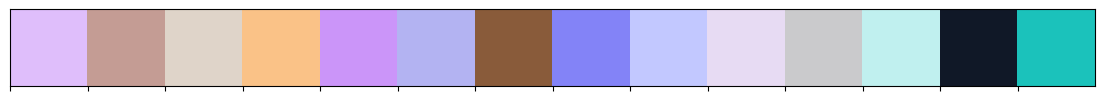

In [36]:
sns.palplot(custom_palette)
plt.show()

In [37]:
def plot_bars(df, col, custom_palette, sort_by='percentage', title="Title TBD", caption='Caption TBD'):
    import pandas as pd
    import plotly.express as px

    counts = df[col].value_counts()
    percentages_raw = df[col].value_counts(normalize=True) * 100

    # Sorting by category vs. percentage as option when wanting to keep categories
    # in their existing order (e.g., marriage years)
    if sort_by == 'category':
        percentages = percentages_raw.sort_index()
    elif sort_by == 'percentage':
        percentages = percentages_raw.sort_values(ascending=False)
    else:
        raise ValueError("sort_by must be 'category' or 'percentage'")

    plot_df = pd.DataFrame({
        "category": percentages.index.astype(str),  # ensure string type
        "percentage": percentages.values
    })

    # Color mapping
    categories = plot_df['category'].tolist()
    color_map = {cat: custom_palette[i % len(custom_palette)] for i, cat in enumerate(categories)}

    # Bar chart
    fig = px.bar(
        plot_df,
        x="category",
        y="percentage",
        text="percentage",
        color="category",
        color_discrete_map=color_map
    )

    # Formatting
    fig.update_layout(
        title=f'{title} Distribution',
        xaxis_title=col,
        yaxis_title="Percentage (%)",
        width=700,
        height=500,
        font=dict(family="Monospace", size=12, color="black"),
        showlegend=False,
        margin=dict(b=130)
)

    # Hover and text formatting
    fig.update_traces(
        texttemplate='%{text:.1f}%',
        textposition='outside',
        customdata=counts.reindex(plot_df['category']).values.reshape(-1,1),
        hovertemplate=f"{col}: %{{x}}<br>" +
                      "Count: %{customdata[0]}<br>" +
                      "Percentage: %{y:.1f}%"
    )

    fig.add_annotation(
    text=caption,
    xref="paper", yref="paper",
    x=0, y=-0.22,
    showarrow=False,
    font=dict(size=14, color="black"),
    xanchor='left', yanchor='top',
    align="left",
    bgcolor="rgba(211, 211, 211, 0.5)",
    bordercolor="gray",
    borderpad=6,
    borderwidth=1
)

    return fig


In [38]:
fig = plot_bars(df, "num_kids", custom_palette, title="Number of Kids", caption="Most of the (divorced) couples had 0 kids (39%) followed by<br>having 1 or 2 kids.")

fig.show()

In [39]:
fig = plot_bars(df,"education_man", custom_palette, title='Education (Man)', caption="Most of the men had a Professional-level education (higher <br>education, post-college) at 57%.")

fig.show()

In [40]:
fig = plot_bars(df,"education_woman", custom_palette, title='Education (Woman)', caption="The women had an even higher makeup of Professional-level education<br>(higher education, post-college) at 62%.")

fig.show()

In [41]:
fig = plot_bars(df,"marriage_decade", custom_palette, title='Marriage Decade', caption="Over 75% of the couples were married in the '90s or '00s.")

fig.show()

In [42]:
fig = plot_bars(df,"marriage_year", custom_palette, title='Marriage Year', sort_by="category", caption="The highest percentage of couples were married in 1998 (5.5%).")

fig.show()

In [43]:
fig = plot_bars(df,"divorce_year", custom_palette, sort_by="category", title='Divorce Year', caption='The highest number of divorces among the couples occurred in <br>2011 (9.8%), with an overall peak between 2008-2011.')

fig.show()

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Histograms.png)



> The histograms here are paired with boxplots. They both help show the distribution of the numerical variables. You can hover over the boxplots to view the min, max, Q1, Q3, and median #s:



In [44]:
def plot_histogram(df,x,nbins,xaxis_title,text):
  fig = px.histogram(df, x=x, nbins=nbins, marginal="box", color_discrete_sequence=['tan'])
  fig.update_layout(
    title=f"{xaxis_title} Distribution",
    xaxis_title=xaxis_title,
    yaxis_title="Count",
    width=600,
    height=400,
    margin=dict(b=115)

  )

  fig.update_xaxes(automargin=True)
  fig.add_annotation(
      text=text,
      xref="paper", yref="paper",
      x=0, y=-0.24,
      showarrow=False,
      font=dict(size=14, color="black"),
      xanchor='left', yanchor='top',
      align="left",
      bgcolor="rgba(211, 211, 211, 0.5)",
      bordercolor="gray",
      borderpad=6,
      borderwidth=1
  )
  fig.show()

In [45]:
plot_histogram(df,"marriage_duration",20,"Marriage Duration",text="The median marriage duration is 8 years. The heaviest<br>concentration is between 2-5 years and the max is 33 years.")


In [46]:
plot_histogram(df,"income_man",15,"Income (Man)",text="The median monthly income for the men was 5,000 dollars <br>with an IQR of 3,200-8,200 dollars and a max of ~19k.")


In [47]:
plot_histogram(df,"income_woman",15,"Income (Woman)",text="The median monthly income for the women was also 5,000 dollars <br>with a bit lower Q3 (7,500 dollars) and max (~15k).")


In [48]:
plot_histogram(df,"age_difference",10,"Age Difference",text="The median age difference of the couple was 2 years, with<br>most ranging from 1-4 years")


In [49]:
plot_histogram(df,"years_woman_older",20,"Years Woman Older",text="The median number of years older of the woman was 1,<br> showing that in most divorced couples the woman was older.")


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Scatterplots.png)

The scatterplots, displayed in a pairplot below, show the relationships between the numerical variables, indicating whether they positive, negative, or neither:

In [50]:
df.columns

Index(['divorce_date', 'dob_man', 'education_man', 'income_man', 'dob_woman',
       'education_woman', 'income_woman', 'marriage_date', 'marriage_duration',
       'num_kids', 'age_difference', 'days_man_older', 'days_woman_older',
       'years_man_older', 'years_woman_older', 'income_difference',
       'marriage_year', 'divorce_year', 'marriage_decade'],
      dtype='object')

In [51]:
pairplot_columns = ['num_kids', 'marriage_duration','income_man','income_woman',
                   'age_difference','years_woman_older',
                   'income_difference','marriage_year']

In [68]:
fig = px.scatter_matrix(
    df,
    dimensions=pairplot_columns,
    title="Pairplot",
    height=1600,
    width=1200)

fig.update_traces(diagonal_visible=False, marker=dict(size=5, opacity=0.7,
                                                      color='cornflowerblue')) # marker size

fig.update_layout(margin=dict(b=250))  # increase bottom margin for caption space
fig.add_annotation(
    text="There is a strong negative correlation between marriage year and marriage duration, showing that the more recent the year the couples were<br> married, the shorter the marriage duration.",
    xref="paper", yref="paper",
    x=0, y=-0.07, # caption position
    showarrow=False,
    font=dict(size=14, color="black"),
    xanchor='left', yanchor='top',
    align="left",
    bgcolor="rgba(211, 211, 211, 0.5)",
    bordercolor="gray",
    borderpad=6,
    borderwidth=1
)
fig.add_annotation(
    text="There is a strong positive correlation between the income of the man and the income of the woman (e.g., if the income of the man is high or <br>low, so is that of the woman)",
    xref="paper", yref="paper",
    x=0, y=-0.13,
    showarrow=False,
    font=dict(size=14, color="black"),
    xanchor='left', yanchor='top',
    align="left",
    bgcolor="rgba(211, 211, 211, 0.5)",
    bordercolor="gray",
    borderpad=6,
    borderwidth=1
)

fig;

In [69]:
fig.show()

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Correlation%20Plots.png)

> The correlations validate the patterns from the scatterplot and also quantify the patterns that are less visible:



In [54]:
df.corr(numeric_only=True, method='pearson')

,income_man,income_woman,marriage_duration,num_kids,age_difference,years_man_older,years_woman_older,income_difference,marriage_year,divorce_year,marriage_decade
income_man,1.000000,0.507815,0.074327,-0.008031,-0.006823,-0.055664,0.055664,0.606732,0.055883,0.218033,0.059821
income_woman,0.507815,1.000000,0.066816,-0.013664,-0.009063,0.002210,-0.002210,-0.376678,0.078684,0.247697,0.069384
marriage_duration,0.074327,0.066816,1.000000,0.568964,-0.032000,0.000402,-0.000402,0.018271,-0.806589,0.006648,-0.757136
num_kids,-0.008031,-0.013664,0.568964,1.000000,-0.101640,-0.020001,0.020001,0.003972,-0.564382,-0.100010,-0.528288
age_difference,-0.006823,-0.009063,-0.032000,-0.101640,1.000000,-0.460084,0.460084,0.001026,0.049308,0.040079,0.041904
years_man_older,-0.055664,0.002210,0.000402,-0.020001,-0.460084,1.000000,-1.000000,-0.061895,0.001715,-0.011158,0.003288
years_woman_older,0.055664,-0.002210,-0.000402,0.020001,0.460084,-1.000000,1.000000,0.061895,-0.001715,0.011158,-0.003288
income_difference,0.606732,-0.376678,0.018271,0.003972,0.001026,-0.061895,0.061895,1.000000,-0.012513,0.005894,0.000303
marriage_year,0.055883,0.078684,-0.806589,-0.564382,0.049308,0.001715,-0.001715,-0.012513,1.000000,0.474033,0.944550
divorce_year,0.218033,0.247697,0.006648,-0.100010,0.040079,-0.011158,0.011158,0.005894,0.474033,1.000000,0.458814


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Heatmaps.png)

> The correlations are best visualized in a heatmap, where their size is easily identifiable:

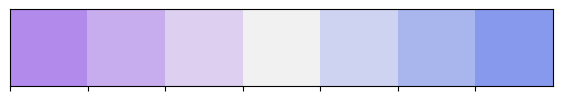

In [55]:
heatmap_palette = sns.diverging_palette(
    6400,  # Hue for end 1
    5300,   # Hue for end 2
    n=7,  # Number of colors
    center="light",  # midpoint lighter
    s=80,  # Saturation
    l=65   # Lightness
)

sns.palplot(heatmap_palette)
plt.show()

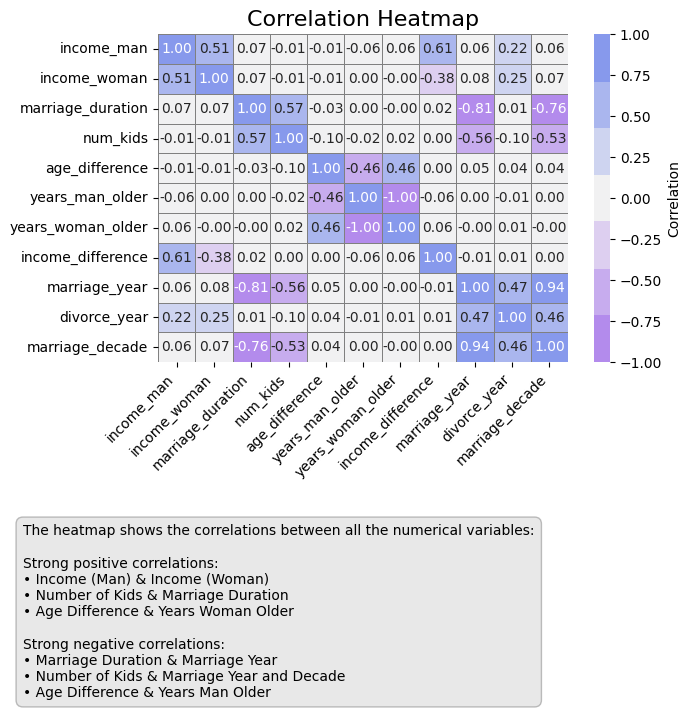

In [56]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap=heatmap_palette,
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Correlation'}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Caption
plt.figtext(
    0.04, -0.40,
    "The heatmap shows the correlations between all the numerical variables:\n"
    "\n"
    "Strong positive correlations:\n"
    "• Income (Man) & Income (Woman)\n"
    "• Number of Kids & Marriage Duration\n"
    "• Age Difference & Years Woman Older\n\n"
    "Strong negative correlations:\n"
    "• Marriage Duration & Marriage Year\n"
    "• Number of Kids & Marriage Year and Decade\n"
    "• Age Difference & Years Man Older",
    fontsize=10,
    color='black',
    wrap=True,
    horizontalalignment='left',
    bbox=dict(facecolor='lightgray', alpha=0.5, edgecolor='gray', boxstyle='round,pad=0.5')
)

plt.show()


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Chi%20Squared.png)

In [57]:
columns_chi = ['education_man','education_woman', 'num_kids','marriage_decade']

df_chi = df[columns_chi].copy()

In [58]:
df_chi.columns

Index(['education_man', 'education_woman', 'num_kids', 'marriage_decade'], dtype='object')

In [59]:
results = []

# Loop through all column pairs
for col1, col2 in combinations(df_chi.columns, 2):

    # Contingency table
    table = pd.crosstab(df_chi[col1], df_chi[col2])

    chi2, p, dof, _ = chi2_contingency(table)

    results.append({
        'feature_1': col1,
        'feature_2': col2,
        'chi2_stat': chi2,
        'p_value': p,
        'dof': dof,
        'significant': p < 0.05
    })

chi_squared_df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
print(chi_squared_df)


         feature_1        feature_2   chi2_stat        p_value  dof  \
0    education_man  education_woman  812.299986  1.503852e-162   16   
1         num_kids  marriage_decade  706.697910  8.467246e-137   20   
2  education_woman  marriage_decade   68.257044   2.011284e-08   16   
3    education_man  marriage_decade   63.559973   1.301178e-07   16   
4  education_woman         num_kids   64.685875   1.309491e-06   20   
5    education_man         num_kids   28.281280   1.029063e-01   20   

   significant  
0         True  
1         True  
2         True  
3         True  
4         True  
5        False  


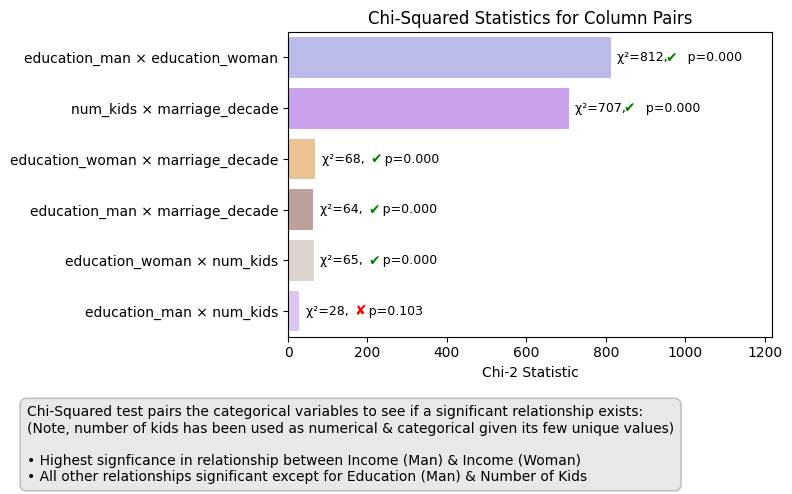

In [60]:
# Combine feature pairs
chi_squared_df['pair'] = chi_squared_df['feature_1'] + " × " + chi_squared_df['feature_2']

plt.figure(figsize=(8, max(4, 0.3*len(chi_squared_df))))  # dynamic height

# Custom palette
unique_hues = chi_squared_df['chi2_stat'].nunique()
palette = custom_palette[:unique_hues]

# Horizontal barplot
ax = sns.barplot(
    data=chi_squared_df,
    x='chi2_stat',
    y='pair',
    hue='chi2_stat',
    palette=palette,
    dodge=False
)

# Annotate bars
for i, row in chi_squared_df.iterrows():
    stat = f"χ²={row['chi2_stat']:.0f}"
    p = f"    p={row['p_value']:.3f}"
    sig_symbol = '✔' if row['significant'] else '✘'
    sig_color = 'green' if row['significant'] else 'red'

    # Add Chi² stat and p-value slightly to the right of the bar
    ax.text(
        row['chi2_stat'] + 0.02*chi_squared_df['chi2_stat'].max(),
        i,
        f"{stat}, {p}",
        va='center',
        ha='left',
        fontsize=9,
        color='black'
    )

    # Add check/x immediately after the stat text
    ax.text(
        row['chi2_stat'] + 0.17*chi_squared_df['chi2_stat'].max(),
        i,
        sig_symbol,
        va='center',
        ha='left',
        fontsize=10,
        color=sig_color,
        fontweight='bold'
    )
    ax.set_xlim(0, chi_squared_df['chi2_stat'].max() * 1.5)

# Caption
plt.figtext(
    0.04, -0.21,
    "Chi-Squared test pairs the categorical variables to see if a significant relationship exists:\n"
    "(Note, number of kids has been used as numerical & categorical given its few unique values)\n"
    "\n"
    "• Highest signficance in relationship between Income (Man) & Income (Woman)\n"
    "• All other relationships significant except for Education (Man) & Number of Kids",
    fontsize=10,
    color='black',
    wrap=True,
    horizontalalignment='left',
    bbox=dict(facecolor='lightgray', alpha=0.5, edgecolor='gray', boxstyle='round,pad=0.5')
)

# Labels and layout
plt.title('Chi-Squared Statistics for Column Pairs')
plt.xlabel('Chi-2 Statistic')
plt.ylabel('')
plt.tight_layout()
plt.legend().remove()
plt.show()


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Linear%20Regression.png)

In [61]:
# dummy variables for marriage decade (since it is now categorical)
df_encoded = pd.get_dummies(df, columns=['marriage_decade'], drop_first=True)

X_data = df[['age_difference','income_difference','num_kids','marriage_decade']].astype(float)

y_target = df['marriage_duration'].astype(float)

x_train, x_test, y_train, y_test = holdout(X_data, y_target, test_size=0.2, random_state=0)

In [62]:
regression = LinearRegression()
regression.fit(x_train, y_train)

LinearRegression()

In [63]:
predictions = regression.predict(x_test)

In [64]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

In [65]:
print(rmse)

4.120341832012853


In [66]:
x_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, x_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      marriage_duration   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     592.6
Date:                Fri, 14 Nov 2025   Prob (F-statistic):          1.53e-308
Time:                        21:43:04   Log-Likelihood:                -4497.0
No. Observations:                1529   AIC:                             9004.
Df Residuals:                    1524   BIC:                             9031.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1054.6045     31.39

In [67]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_data.columns
vif_data["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(X_data.shape[1])]

print(vif_data)

             feature       VIF
0     age_difference  2.018059
1  income_difference  1.042740
2           num_kids  2.062001
3    marriage_decade  3.304745


The linear regression model shows an Adjusted R^2 of 0.608 which is strong, especially given the small # of variables in the model. This means that the variables in the model are able to explain 60.8% of the variance in marriage duration.

The number of kids and the marriage decade are significant, with number of kids having a positive relationship (coefficient: 1.66) and marriage decade having a negative relationship (-0.52). This means that there was a longer marriage duration the more kids the couple had and the earlier the marriage decade.

There is an moderate amount of multicollinearity with marriage decade & number of kids, as shown in the previous chi-squared test and in the VIF check above, which is prompting the condition number above to flag multicollinearity in the model. However, the VIF is less than 10 for each features, which is acceptable and does not warrant removal of any variables.

A next step for this data could be to segment the data by marriage duration or perform clustering to see the different patterns (num_kids, income, education dist).